In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "student_id": range(1, n+1),
    "math": np.random.randint(40, 100, n),
    "science": np.random.randint(35, 100, n),
    "english": np.random.randint(45, 100, n),
    "attendance_percent": np.random.randint(60, 100, n)
}

df = pd.DataFrame(data)

df.head()

,student_id,math,science,english,attendance_percent
0,1,78,93,96,98
1,2,91,62,60,73
2,3,68,76,57,90
3,4,54,79,94,64
4,5,82,96,86,94


In [2]:
df["total_score"] = df["math"] + df["science"] + df["english"]
df["average_score"] = df["total_score"] / 3

In [3]:
def classify(avg):
    if avg >= 80:
        return "A"
    elif avg >= 60:
        return "B"
    else:
        return "C"

df["grade"] = df["average_score"].apply(classify)

In [4]:
weights = np.array([0.4, 0.35, 0.25])

scores = df[["math","science","english"]].values

df["weighted_score"] = np.dot(scores, weights)

In [5]:
df["math_z"] = (df["math"] - np.mean(df["math"])) / np.std(df["math"])
df["science_z"] = (df["science"] - np.mean(df["science"])) / np.std(df["science"])
df["english_z"] = (df["english"] - np.mean(df["english"])) / np.std(df["english"])

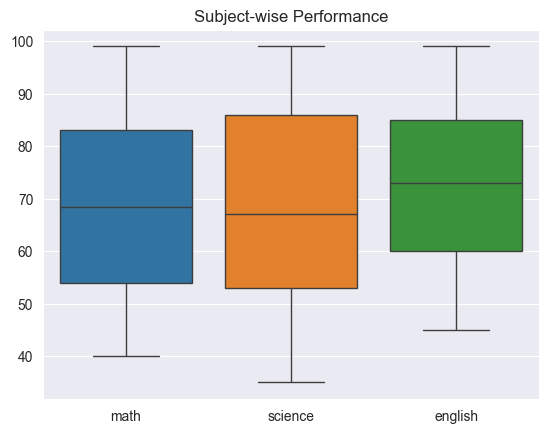

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[["math","science","english"]])
plt.title("Subject-wise Performance")
plt.show()

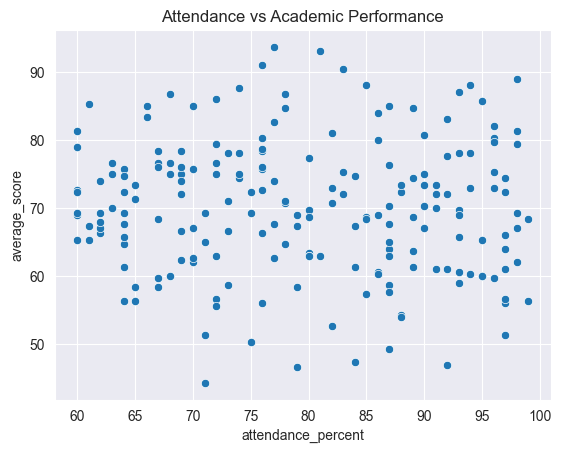

In [7]:
sns.scatterplot(x="attendance_percent", y="average_score", data=df)
plt.title("Attendance vs Academic Performance")
plt.show()